# Global Solar Atlas — Porto Alegre Transformation

Clips Brazil-wide GeoTIFF layers from the Global Solar Atlas (v2, LTAy AvgDailyTotals)
to Porto Alegre city extent, writes clipped GeoTIFFs, and computes neighbourhood-level
solar averages for use in the No-Regret Actions workshop.

**Inputs:**
- `Brazil_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF/{GHI,PVOUT,DNI,GTI,DIF}.tif`
- `../br_ibge/release/2022/output/porto_alegre_neighbourhoods.geojson`

**Outputs:**
- `output/poa_GHI.tif`, `output/poa_PVOUT.tif`, … (clipped GeoTIFFs)
- `output/poa_solar_pixels.csv` — pixel-level table with lat/lon/values
- `output/poa_solar_neighbourhoods.csv` — neighbourhood averages (joinable to indicators GeoJSON)
- `output/poa_solar_neighbourhoods.geojson` — neighbourhoods with solar attributes

**Notes:**
- GHI / DNI / DIF / GTI: 0.0025° (~250 m) resolution
- PVOUT: 0.00833° (~930 m) resolution
- Units: kWh/m²/day (GHI, DNI, DIF, GTI) | kWh/kWp/day (PVOUT)

In [10]:
import struct
import zlib
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## 1. Configuration

In [18]:
# ── Paths ───────────────────────────────────────────────────────────────────
SOLAR_DIR   = Path('Brazil_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF')
IBGE_DIR    = Path('../../br_ibge/release/2010/output')
OUTPUT_DIR  = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Porto Alegre bounding box (with ~5 km buffer) ────────────────────────────
# Official extent: lon -51.32 to -51.00, lat -30.35 to -29.95
POA_WEST  = -51.40
POA_EAST  = -50.90
POA_SOUTH = -30.45
POA_NORTH = -29.85

# ── Layers to process ────────────────────────────────────────────────────────
# (filename_stem, description, units)
LAYERS = [
    ('GHI',   'Global Horizontal Irradiance',      'kWh/m²/day'),
    ('PVOUT', 'PV Output',                          'kWh/kWp/day'),
    ('DNI',   'Direct Normal Irradiance',           'kWh/m²/day'),
    ('GTI',   'Global Tilted Irradiance',           'kWh/m²/day'),
    ('DIF',   'Diffuse Horizontal Irradiance',      'kWh/m²/day'),
]

print(f'Output directory: {OUTPUT_DIR.resolve()}')
print(f'Bounding box: W={POA_WEST} E={POA_EAST} S={POA_SOUTH} N={POA_NORTH}')

Output directory: /Users/amandaeames/Documents/gitrepo/geospatial-data/transformation/global_solar_atlas/v2/output
Bounding box: W=-51.4 E=-50.9 S=-30.45 N=-29.85


## 2. Helpers — GeoTIFF Metadata & Clipping

In [12]:
def read_geotiff_meta(tif_path):
    """Parse GeoTIFF header tags: returns dict with pixel_scale, tie_point, width, height."""
    dtype_sizes = {1:1,2:1,3:2,4:4,5:8,6:1,7:1,8:2,9:4,10:8,11:4,12:8}
    with open(tif_path, 'rb') as f:
        bom = f.read(2)
        end = '<' if bom == b'II' else '>'
        f.read(2)  # magic
        ifd_offset = struct.unpack(end + 'I', f.read(4))[0]
        f.seek(ifd_offset)
        n = struct.unpack(end + 'H', f.read(2))[0]
        tags = {}
        for _ in range(n):
            tag   = struct.unpack(end + 'H', f.read(2))[0]
            dtype = struct.unpack(end + 'H', f.read(2))[0]
            count = struct.unpack(end + 'I', f.read(4))[0]
            vraw  = f.read(4)
            pos   = f.tell()
            sz    = dtype_sizes.get(dtype, 1)
            if count * sz <= 4:
                if dtype == 3:  val = struct.unpack(end + 'H', vraw[:2])[0]
                elif dtype == 4: val = struct.unpack(end + 'I', vraw)[0]
                elif dtype == 12: val = struct.unpack(end + 'd', vraw)[0]
                else: val = vraw
            else:
                off = struct.unpack(end + 'I', vraw)[0]
                f.seek(off)
                if dtype == 3:  val = [struct.unpack(end+'H', f.read(2))[0] for _ in range(count)]
                elif dtype == 4: val = [struct.unpack(end+'I', f.read(4))[0] for _ in range(count)]
                elif dtype == 12: val = [struct.unpack(end+'d', f.read(8))[0] for _ in range(count)]
                else: val = f.read(count * sz)
                f.seek(pos)
            tags[tag] = val

    scale = tags[33550]      # ModelPixelScale: [sx, sy, 0]
    tp    = tags[33922]      # ModelTiepoint: [i,j,k, x,y,z]
    return {
        'width':        tags[256] if isinstance(tags[256], int) else tags[256][-1],
        'height':       tags[257] if isinstance(tags[257], int) else tags[257][-1],
        'pixel_size_x': scale[0],
        'pixel_size_y': scale[1],
        'origin_x':     tp[3],   # top-left corner longitude
        'origin_y':     tp[4],   # top-left corner latitude
    }


def bbox_to_pixel_slice(meta, west, east, south, north):
    """Convert geographic bbox to (row_start, row_end, col_start, col_end) pixel indices."""
    ox, oy = meta['origin_x'], meta['origin_y']
    sx, sy = meta['pixel_size_x'], meta['pixel_size_y']
    col_start = max(0, int(math.floor((west  - ox) / sx)))
    col_end   = min(meta['width'],  int(math.ceil( (east  - ox) / sx)))
    row_start = max(0, int(math.floor((oy - north) / sy)))
    row_end   = min(meta['height'], int(math.ceil( (oy - south) / sy)))
    return row_start, row_end, col_start, col_end


def pixel_to_latlon(meta, row, col):
    """Return the centre lat/lon of a pixel at (row, col)."""
    lon = meta['origin_x'] + (col + 0.5) * meta['pixel_size_x']
    lat = meta['origin_y'] - (row + 0.5) * meta['pixel_size_y']
    return lat, lon

print('Helpers loaded')

Helpers loaded


## 3. Clip All Layers to Porto Alegre Extent

In [13]:
clipped = {}   # layer_name → {'array': np.ndarray, 'meta': dict, 'clip_meta': dict}

for stem, desc, units in LAYERS:
    tif_path = SOLAR_DIR / f'{stem}.tif'
    if not tif_path.exists():
        print(f'  SKIP {stem} — file not found')
        continue

    meta = read_geotiff_meta(tif_path)
    r0, r1, c0, c1 = bbox_to_pixel_slice(meta, POA_WEST, POA_EAST, POA_SOUTH, POA_NORTH)

    arr_full = iio.imread(tif_path)          # full Brazil extent as float32 array
    arr_clip = arr_full[r0:r1, c0:c1].copy()

    # Clip metadata: new origin = top-left corner of clipped region
    clip_meta = {
        **meta,
        'width':    c1 - c0,
        'height':   r1 - r0,
        'origin_x': meta['origin_x'] + c0 * meta['pixel_size_x'],
        'origin_y': meta['origin_y'] - r0 * meta['pixel_size_y'],
    }

    clipped[stem] = {'array': arr_clip, 'meta': clip_meta, 'desc': desc, 'units': units}

    valid = np.sum(~np.isnan(arr_clip))
    print(f'  {stem:6s}  shape={arr_clip.shape}  '
          f'res={meta["pixel_size_x"]*111320:.0f}m  '
          f'valid_px={valid}  '
          f'mean={np.nanmean(arr_clip):.2f} {units}')

print('\nClipping complete.')

  GHI     shape=(240, 200)  res=278m  valid_px=48000  mean=4.62 kWh/m²/day
  PVOUT   shape=(72, 60)  res=928m  valid_px=4320  mean=4.06 kWh/kWp/day
  DNI     shape=(240, 200)  res=278m  valid_px=48000  mean=4.47 kWh/m²/day
  GTI     shape=(240, 200)  res=278m  valid_px=48000  mean=5.04 kWh/m²/day
  DIF     shape=(240, 200)  res=278m  valid_px=48000  mean=1.79 kWh/m²/day

Clipping complete.


## 4. Write Clipped GeoTIFFs

Writes uncompressed Float32 GeoTIFFs with WGS84 CRS (EPSG:4326) tags.
These can be opened directly in QGIS, ArcGIS, or any GIS tool.

In [14]:
def write_geotiff_f32(out_path, arr, origin_x, origin_y, pixel_size_x, pixel_size_y):
    """
    Write a single-band Float32 GeoTIFF with WGS84 (EPSG:4326) projection.
    Uses a single strip (whole image) for maximum compatibility.
    NaN values are stored as -9999.
    """
    height, width = arr.shape
    data = arr.astype(np.float32)
    data[np.isnan(data)] = -9999.0
    img_bytes = data.tobytes()

    # ── GeoKey directory for WGS84 Geographic CRS ──────────────────────────
    geokeys_shorts = [
        1, 1, 0, 3,          # Header: version=1, revision=1, minor=0, nkeys=3
        1024, 0, 1, 2,       # GTModelTypeGeoKey = 2 (Geographic)
        1025, 0, 1, 1,       # GTRasterTypeGeoKey = 1 (PixelIsArea)
        2048, 0, 1, 4326,    # GeographicTypeGeoKey = 4326 (WGS84)
    ]

    pixel_scale_bytes = struct.pack('<3d', pixel_size_x, pixel_size_y, 0.0)
    tiepoint_bytes    = struct.pack('<6d', 0.0, 0.0, 0.0, origin_x, origin_y, 0.0)

    # ── IFD layout (13 tags, single-strip image) ────────────────────────────
    n_tags      = 13
    ifd_size    = 2 + n_tags * 12 + 4
    extra_start = 8 + ifd_size

    ps_off   = extra_start
    tp_off   = ps_off + len(pixel_scale_bytes)
    gk_off   = tp_off + len(tiepoint_bytes)
    img_off  = gk_off + len(geokeys_shorts) * 2
    total_bytes = width * height * 4

    def ifd_entry(tag, dtype, count, value_or_offset):
        return struct.pack('<HHI', tag, dtype, count) + struct.pack('<I', value_or_offset)

    ifd_entries = b''.join([
        ifd_entry(256,  4, 1, width),
        ifd_entry(257,  4, 1, height),
        ifd_entry(258,  3, 1, 32),
        ifd_entry(259,  3, 1, 1),             # Compression: none
        ifd_entry(262,  3, 1, 1),             # PhotometricInterp
        ifd_entry(273,  4, 1, img_off),       # StripOffsets (1 strip)
        ifd_entry(278,  4, 1, height),        # RowsPerStrip = all rows
        ifd_entry(279,  4, 1, total_bytes),   # StripByteCounts (1 strip)
        ifd_entry(284,  3, 1, 1),             # PlanarConfiguration
        ifd_entry(339,  3, 1, 3),             # SampleFormat: float
        ifd_entry(33550, 12, 3, ps_off),
        ifd_entry(33922, 12, 6, tp_off),
        ifd_entry(34735,  3, len(geokeys_shorts), gk_off),
    ])

    buf = bytearray()
    buf += b'II'
    buf += struct.pack('<H', 42)
    buf += struct.pack('<I', 8)
    buf += struct.pack('<H', n_tags)
    buf += ifd_entries
    buf += struct.pack('<I', 0)   # next IFD
    buf += pixel_scale_bytes
    buf += tiepoint_bytes
    buf += struct.pack(f'<{len(geokeys_shorts)}H', *geokeys_shorts)
    buf += img_bytes

    with open(out_path, 'wb') as f:
        f.write(buf)

print('GeoTIFF writer loaded  (nodata=-9999, single-strip, WGS84)')


GeoTIFF writer loaded  (nodata=-9999, single-strip, WGS84)


In [15]:
for stem, layer in clipped.items():
    out_path = OUTPUT_DIR / f'poa_{stem}.tif'
    m = layer['meta']
    write_geotiff_f32(
        out_path,
        layer['array'],
        origin_x     = m['origin_x'],
        origin_y     = m['origin_y'],
        pixel_size_x = m['pixel_size_x'],
        pixel_size_y = m['pixel_size_y'],
    )
    size_kb = out_path.stat().st_size / 1024
    print(f'  Wrote {out_path.name}  ({size_kb:.0f} KB)')

print('\nAll GeoTIFFs written.')

  Wrote poa_GHI.tif  (188 KB)
  Wrote poa_PVOUT.tif  (17 KB)
  Wrote poa_DNI.tif  (188 KB)
  Wrote poa_GTI.tif  (188 KB)
  Wrote poa_DIF.tif  (188 KB)

All GeoTIFFs written.


## 5. Pixel-Level CSV

Flat table: one row per GHI pixel with `lat`, `lon`, and all layer values at that location.
Useful for quick scatter plots or importing into any mapping tool.

In [19]:
# Anchor pixel grid on GHI (highest resolution, 250 m)
base = clipped['GHI']
bm   = base['meta']
rows, cols = base['array'].shape

# Build coordinate arrays
row_idx = np.arange(rows)
col_idx = np.arange(cols)
lats = bm['origin_y'] - (row_idx + 0.5) * bm['pixel_size_y']
lons = bm['origin_x'] + (col_idx + 0.5) * bm['pixel_size_x']
lon_grid, lat_grid = np.meshgrid(lons, lats)

df_pixels = pd.DataFrame({
    'lat': lat_grid.ravel(),
    'lon': lon_grid.ravel(),
})

# Add each layer, resampling to GHI grid if needed
for stem, layer in clipped.items():
    arr   = layer['array']
    meta  = layer['meta']
    if arr.shape == base['array'].shape:
        df_pixels[stem] = arr.ravel()
    else:
        # Nearest-neighbour lookup onto GHI grid
        def nn_lookup(lat_arr, lon_arr, src_arr, src_meta):
            ox, oy = src_meta['origin_x'], src_meta['origin_y']
            sx, sy = src_meta['pixel_size_x'], src_meta['pixel_size_y']
            col_i = np.clip(((lon_arr - ox) / sx).astype(int), 0, src_arr.shape[1]-1)
            row_i = np.clip(((oy - lat_arr) / sy).astype(int), 0, src_arr.shape[0]-1)
            return src_arr[row_i, col_i]
        df_pixels[stem] = nn_lookup(lat_grid.ravel(), lon_grid.ravel(), arr, meta)

# Drop rows where all solar values are NaN
solar_cols = list(clipped.keys())
df_pixels = df_pixels.dropna(subset=solar_cols, how='all')

# Round for compact output
for col in solar_cols:
    df_pixels[col] = df_pixels[col].round(3)

out_csv = OUTPUT_DIR / 'poa_solar_pixels.csv'
df_pixels.to_csv(out_csv, index=False)
print(f'Pixel CSV: {len(df_pixels):,} rows → {out_csv.name}  ({out_csv.stat().st_size/1024:.0f} KB)')
df_pixels.head()

Pixel CSV: 48,000 rows → poa_solar_pixels.csv  (2598 KB)


,lat,lon,GHI,PVOUT,DNI,GTI,DIF
0,-29.85125,-51.39875,4.604,4.029,4.409,5.012,1.796
1,-29.85125,-51.39625,4.606,4.029,4.418,5.014,1.796
2,-29.85125,-51.39375,4.607,4.029,4.418,5.015,1.796
3,-29.85125,-51.39125,4.608,4.031,4.422,5.016,1.796
4,-29.85125,-51.38875,4.610,4.031,4.426,5.018,1.796


## 6. Neighbourhood-Level Averages

Spatially assigns each pixel to a neighbourhood polygon (ray-casting point-in-polygon)
and computes mean solar values per neighbourhood.
Output joins to the IBGE indicators GeoJSON on `neighbourhood_number`.

In [20]:
# ── Load neighbourhood polygons ──────────────────────────────────────────────
nb_geojson_path = IBGE_DIR / 'porto_alegre_neighbourhoods.geojson'

if not nb_geojson_path.exists():
    print(f'WARNING: {nb_geojson_path} not found — skipping neighbourhood averages.')
    print('Run the IBGE transformation notebook first, or adjust IBGE_DIR.')
    neighbourhoods = None
else:
    with open(nb_geojson_path) as f:
        nb_fc = json.load(f)
    neighbourhoods = nb_fc['features']
    print(f'Loaded {len(neighbourhoods)} neighbourhood polygons')

    # Print first feature to verify property names
    print('Sample properties:', list(neighbourhoods[0]['properties'].keys()))

Loaded 99 neighbourhood polygons
Sample properties: ['neighbourhood_number', 'neighbourhood_name']


In [21]:
def point_in_polygon(px, py, polygon_coords):
    """
    Ray-casting point-in-polygon test.
    polygon_coords: list of (lon, lat) tuples (exterior ring, closed).
    Returns True if point (px, py) is inside the polygon.
    """
    n = len(polygon_coords)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = polygon_coords[i]
        xj, yj = polygon_coords[j]
        if ((yi > py) != (yj > py)) and (px < (xj - xi) * (py - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside


def vectorised_pip(lons_arr, lats_arr, polygon_coords):
    """
    Vectorised ray-casting for a 1-D array of points against one polygon.
    Returns boolean mask.
    """
    coords = np.array(polygon_coords)  # (N, 2) → x=lon, y=lat
    x, y = coords[:, 0], coords[:, 1]
    inside = np.zeros(len(lons_arr), dtype=bool)
    j = len(x) - 1
    for i in range(len(x)):
        cond = (y[i] > lats_arr) != (y[j] > lats_arr)
        xsect = (x[j] - x[i]) * (lats_arr - y[i]) / (y[j] - y[i] + 1e-15) + x[i]
        inside ^= cond & (lons_arr < xsect)
        j = i
    return inside


def get_exterior_ring(geometry):
    """Extract exterior ring coords from a GeoJSON geometry (Polygon or MultiPolygon)."""
    if geometry['type'] == 'Polygon':
        return [geometry['coordinates'][0]]  # list of rings
    elif geometry['type'] == 'MultiPolygon':
        return [part[0] for part in geometry['coordinates']]
    return []

print('PiP helpers loaded')

PiP helpers loaded


In [22]:
if neighbourhoods is None:
    print('Skipped — neighbourhood file not found.')
else:
    pixel_lons = df_pixels['lon'].to_numpy()
    pixel_lats = df_pixels['lat'].to_numpy()

    results = []
    for feat in neighbourhoods:
        props = feat['properties']
        nb_num  = props.get('neighbourhood_number')
        nb_name = props.get('neighbourhood_name')
        geom    = feat['geometry']

        # Build bounding box filter first (fast pre-screen)
        rings = get_exterior_ring(geom)
        all_coords = [c for ring in rings for c in ring]
        if not all_coords:
            continue
        xs = [c[0] for c in all_coords]
        ys = [c[1] for c in all_coords]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)

        # Pre-screen pixels by bounding box
        bb_mask = (
            (pixel_lons >= min_x) & (pixel_lons <= max_x) &
            (pixel_lats >= min_y) & (pixel_lats <= max_y)
        )
        candidates_idx = np.where(bb_mask)[0]

        if len(candidates_idx) == 0:
            continue

        # PiP test on candidates
        inside_mask = np.zeros(len(candidates_idx), dtype=bool)
        for ring in rings:
            inside_mask |= vectorised_pip(
                pixel_lons[candidates_idx],
                pixel_lats[candidates_idx],
                ring
            )

        inside_idx = candidates_idx[inside_mask]
        if len(inside_idx) == 0:
            continue

        row = {'neighbourhood_number': nb_num, 'neighbourhood_name': nb_name,
               'n_solar_pixels': len(inside_idx)}
        for col in solar_cols:
            vals = df_pixels[col].to_numpy()[inside_idx]
            row[f'{col}_mean'] = round(float(np.nanmean(vals)), 3)
            row[f'{col}_max']  = round(float(np.nanmax(vals)), 3)
        results.append(row)

    df_nb = pd.DataFrame(results)
    print(f'Computed solar averages for {len(df_nb)}/{len(neighbourhoods)} neighbourhoods')
    df_nb.head()

Computed solar averages for 97/99 neighbourhoods


In [23]:
if neighbourhoods is not None and len(df_nb) > 0:

    # ── CSV output ───────────────────────────────────────────────────────────
    out_nb_csv = OUTPUT_DIR / 'poa_solar_neighbourhoods.csv'
    df_nb.to_csv(out_nb_csv, index=False)
    print(f'Neighbourhood CSV → {out_nb_csv.name}  ({out_nb_csv.stat().st_size/1024:.0f} KB)')

    # ── GeoJSON output (join solar cols back to geometry) ────────────────────
    df_nb_unique = df_nb.drop_duplicates(subset='neighbourhood_number', keep='first')
    nb_lookup = df_nb_unique.set_index('neighbourhood_number').to_dict('index')
    out_features = []
    for feat in neighbourhoods:
        nb_num = feat['properties'].get('neighbourhood_number')
        props = dict(feat['properties'])
        if nb_num in nb_lookup:
            solar_vals = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v)
                          for k, v in nb_lookup[nb_num].items()}
            props.update(solar_vals)
        out_features.append({'type': 'Feature', 'properties': props, 'geometry': feat['geometry']})

    out_geojson = OUTPUT_DIR / 'poa_solar_neighbourhoods.geojson'
    with open(out_geojson, 'w') as f:
        json.dump({'type': 'FeatureCollection', 'features': out_features}, f, indent=2)
    size_kb = out_geojson.stat().st_size / 1024
    print(f'Neighbourhood GeoJSON → {out_geojson.name}  ({size_kb:.0f} KB)')
    print(f'\nColumns: {list(df_nb.columns)}')

Neighbourhood CSV → poa_solar_neighbourhoods.csv  (8 KB)


ValueError: DataFrame index must be unique for orient='index'.

## 7. Quick Visualisation Check

Raster preview of GHI and neighbourhood-level PVOUT choropleth.

/var/folders/sb/7n1bm8g546s726d75lp545wm0000gn/T/ipykernel_7349/3245730036.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


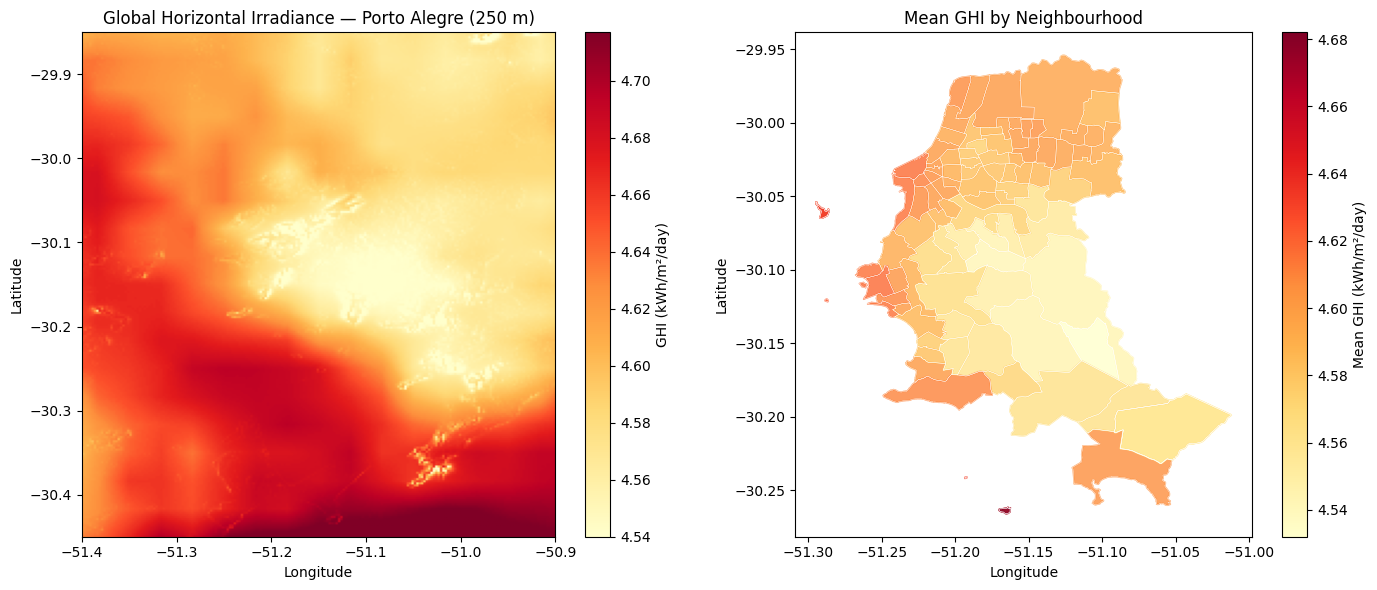

Preview saved → poa_solar_preview.png


In [28]:
# ── Plot 1: GHI raster heatmap ───────────────────────────────────────────────
ghi_arr = clipped['GHI']['array']
m = clipped['GHI']['meta']

extent = [
    m['origin_x'],
    m['origin_x'] + m['width']  * m['pixel_size_x'],
    m['origin_y'] - m['height'] * m['pixel_size_y'],
    m['origin_y'],
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(
    ghi_arr, origin='upper',
    extent=extent,
    cmap='YlOrRd', aspect='auto',
    vmin=np.nanpercentile(ghi_arr, 2),
    vmax=np.nanpercentile(ghi_arr, 98)
)
plt.colorbar(im, ax=axes[0], label='GHI (kWh/m²/day)')
axes[0].set_title('Global Horizontal Irradiance — Porto Alegre (250 m)')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

# ── Plot 2: Neighbourhood GHI choropleth ────────────────────────────────────
if neighbourhoods is not None and len(df_nb) > 0:
    import matplotlib.cm as cm
    ghi_vals = df_nb['GHI_mean'].to_numpy()
    norm = mcolors.Normalize(vmin=np.nanmin(ghi_vals), vmax=np.nanmax(ghi_vals))
    cmap = cm.get_cmap('YlOrRd')

    nb_by_num = {feat['properties']['neighbourhood_number']: feat for feat in neighbourhoods}
    for _, row in df_nb.iterrows():
        feat = nb_by_num.get(row['neighbourhood_number'])
        if feat is None:
            continue
        color = cmap(norm(row['GHI_mean']))
        geom = feat['geometry']
        rings = get_exterior_ring(geom)
        for ring in rings:
            xs = [c[0] for c in ring]
            ys = [c[1] for c in ring]
            axes[1].fill(xs, ys, color=color, alpha=0.8)
            axes[1].plot(xs, ys, color='white', linewidth=0.3)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='Mean GHI (kWh/m²/day)')
    axes[1].set_title('Mean GHI by Neighbourhood')
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
    axes[1].set_aspect('equal')
else:
    axes[1].text(0.5, 0.5, 'Neighbourhood file not found', ha='center', va='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
out_fig = OUTPUT_DIR / 'poa_solar_preview.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Preview saved → {out_fig.name}')

## 8. Summary of Outputs

| File | Description |
|------|-------------|
| `output/poa_GHI.tif` | Clipped GHI raster (250 m, EPSG:4326) |
| `output/poa_PVOUT.tif` | Clipped PV Output raster (930 m, EPSG:4326) |
| `output/poa_DNI.tif` | Clipped Direct Normal Irradiance |
| `output/poa_GTI.tif` | Clipped Global Tilted Irradiance |
| `output/poa_DIF.tif` | Clipped Diffuse Horizontal Irradiance |
| `output/poa_solar_pixels.csv` | Pixel-level CSV with lat/lon + all layer values |
| `output/poa_solar_neighbourhoods.csv` | Neighbourhood-level mean/max per layer |
| `output/poa_solar_neighbourhoods.geojson` | Neighbourhood polygons with solar attributes |
| `output/poa_solar_preview.png` | Quick visual check (raster + choropleth) |

**Joining to IBGE indicators:**  
Both `poa_solar_neighbourhoods.csv` and `porto_alegre_indicators.geojson` share the  
`neighbourhood_number` key — merge on that column to get a single combined layer.